# 03 - Autoencoder Baseline Experiments

Our first modeling idea: train a **convolutional autoencoder** on defect free images only. The network learns to compress and reconstruct normal appearance. At test time a defective region should reconstruct poorly because the model has never seen defects, so the **pixel wise reconstruction error becomes the anomaly signal**.

This notebook prototypes the architecture, runs a short training experiment on the bottle category and validates the whole detection idea end to end. The full training runs (100 epochs with early stopping for all three categories) were then moved to `scripts/train_baseline.py`.

**Note:** run this notebook inside the project `.venv` since it requires PyTorch. A GPU helps but CPU works for the short experiment here.

In [7]:
!python -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128


In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms

DATA_ROOT = Path('../data/mvtec_ad')
IMG_SIZE = 256
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(42)
np.random.seed(42)
print('device:', DEVICE)

device: cpu


## 1. Architecture Design

A symmetric encoder decoder with four blocks each:

- **Encoder:** Conv2d with stride 2 halves the spatial size at every block while channels grow 3 to 32 to 64 to 128 to 256. Strided convolution is a learned downsampling operation, replacing fixed pooling. Each block adds BatchNorm2d for training stability and ReLU.
- **Bottleneck:** a 256x256x3 input becomes a 16x16x256 latent code. The compression forces the network to keep only the regular structure of normal images.
- **Decoder:** ConvTranspose2d with stride 2 mirrors the encoder and doubles the spatial size at every block, 256 to 128 to 64 to 32 to 3 channels. The final Sigmoid keeps the output in [0, 1], the same range as the normalized input.

The result is a small model of roughly 1.1 million parameters, intentionally simple since this is the baseline.

In [3]:
class Encoder(nn.Module):
    """256x256x3 -> 16x16x256"""

    def __init__(self):
        super().__init__()
        channels = [3, 32, 64, 128, 256]
        layers = []
        for c_in, c_out in zip(channels[:-1], channels[1:]):
            layers += [
                nn.Conv2d(c_in, c_out, kernel_size=3, stride=2, padding=1),
                nn.BatchNorm2d(c_out),
                nn.ReLU(inplace=True),
            ]
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)


class Decoder(nn.Module):
    """16x16x256 -> 256x256x3"""

    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),  # output in [0, 1] to match the input range
        )

    def forward(self, x):
        return self.layers(x)


class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        latent = self.encoder(x)
        return self.decoder(latent), latent

    def get_anomaly_map(self, x):
        """Pixel wise MSE between input and reconstruction."""
        reconstruction, _ = self.forward(x)
        return torch.mean((x - reconstruction) ** 2, dim=1, keepdim=True)

    def get_image_score(self, anomaly_map, top_k=100):
        """Image score = mean of the top k pixel errors (robust to noise)."""
        flat = anomaly_map.view(anomaly_map.shape[0], -1)
        topk_vals, _ = torch.topk(flat, k=min(top_k, flat.shape[1]), dim=1)
        return topk_vals.mean(dim=1)

## 2. Sanity Checks

Before any training we verify the parameter count and that a random tensor flows through with the expected shapes.

In [4]:
model = ConvAutoencoder()
total = sum(p.numel() for p in model.parameters())
print(f'parameters: {total:,}')

x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
recon, latent = model(x)
amap = model.get_anomaly_map(x)
scores = model.get_image_score(amap)
print(f'input          {tuple(x.shape)}')
print(f'latent         {tuple(latent.shape)}')
print(f'reconstruction {tuple(recon.shape)}')
print(f'anomaly map    {tuple(amap.shape)}')
print(f'image scores   {tuple(scores.shape)}')

parameters: 1,079,715
input          (2, 3, 256, 256)
latent         (2, 256, 16, 16)
reconstruction (2, 3, 256, 256)
anomaly map    (2, 1, 256, 256)
image scores   (2,)


## 3. Data Loading

A compact version of the loader worked out in the preprocessing notebook: bilinear resize plus [0, 1] scaling for images, nearest resize plus binarization for masks and a reproducible validation split with seed 42.

In [5]:
img_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
mask_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE),
                      interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor(),
])


class MVTecDataset(Dataset):
    def __init__(self, root, category, split='train'):
        self.samples = []
        cat_dir = Path(root) / category
        if split == 'train':
            for p in sorted((cat_dir / 'train' / 'good').glob('*.png')):
                self.samples.append((p, None, 0, 'good'))
        else:
            for d in sorted((cat_dir / 'test').iterdir()):
                if not d.is_dir():
                    continue
                for p in sorted(d.glob('*.png')):
                    mp = None
                    if d.name != 'good':
                        cand = cat_dir / 'ground_truth' / d.name / (p.stem + '_mask.png')
                        mp = cand if cand.exists() else None
                    self.samples.append((p, mp, 0 if d.name == 'good' else 1, d.name))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        p, mp, label, defect_type = self.samples[idx]
        image = img_tf(Image.open(p).convert('RGB'))
        if mp is not None:
            mask = (mask_tf(Image.open(mp).convert('L')) > 0.5).float()
        else:
            mask = torch.zeros(1, IMG_SIZE, IMG_SIZE)
        return {'image': image, 'mask': mask, 'label': label, 'defect_type': defect_type}


CATEGORY = 'bottle'
full_train = MVTecDataset(DATA_ROOT, CATEGORY, 'train')
val_size = max(1, int(len(full_train) * 0.1))
train_ds, val_ds = random_split(full_train, [len(full_train) - val_size, val_size],
                                generator=torch.Generator().manual_seed(42))
test_ds = MVTecDataset(DATA_ROOT, CATEGORY, 'test')

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16)
test_loader = DataLoader(test_ds, batch_size=16)
print(f'{CATEGORY}: train {len(train_ds)}, val {len(val_ds)}, test {len(test_ds)}')

bottle: train 189, val 20, test 83


## 4. A Short Training Experiment

We train with MSE reconstruction loss and the Adam optimizer for a small number of epochs, just enough to see whether the loss drops and the reconstruction becomes meaningful. The training loop below is exactly the loop that later grew into `scripts/train_baseline.py`, which adds early stopping (patience 10), a ReduceLROnPlateau scheduler and best checkpoint saving.

In [6]:
EPOCHS = 15  # short experiment; the full runs use up to 100 with early stopping

model = ConvAutoencoder().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

history = {'train': [], 'val': []}
for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        images = batch['image'].to(DEVICE)
        optimizer.zero_grad()
        reconstruction, _ = model(images)
        loss = criterion(reconstruction, images)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            images = batch['image'].to(DEVICE)
            reconstruction, _ = model(images)
            val_loss += criterion(reconstruction, images).item()
    val_loss /= len(val_loader)

    history['train'].append(train_loss)
    history['val'].append(val_loss)
    print(f'epoch {epoch:2d}/{EPOCHS} | train {train_loss:.6f} | val {val_loss:.6f}')

epoch  1/15 | train 0.076414 | val 0.076119
epoch  2/15 | train 0.020585 | val 0.029145
epoch  3/15 | train 0.008410 | val 0.016436
epoch  4/15 | train 0.005234 | val 0.006363
epoch  5/15 | train 0.004044 | val 0.004148
epoch  6/15 | train 0.003390 | val 0.003607
epoch  7/15 | train 0.002992 | val 0.003339
epoch  8/15 | train 0.002692 | val 0.002993
epoch  9/15 | train 0.002430 | val 0.003149
epoch 10/15 | train 0.002130 | val 0.002714
epoch 11/15 | train 0.001840 | val 0.002033
epoch 12/15 | train 0.001584 | val 0.001571
epoch 13/15 | train 0.001412 | val 0.001452
epoch 14/15 | train 0.001286 | val 0.001267
epoch 15/15 | train 0.001175 | val 0.001206


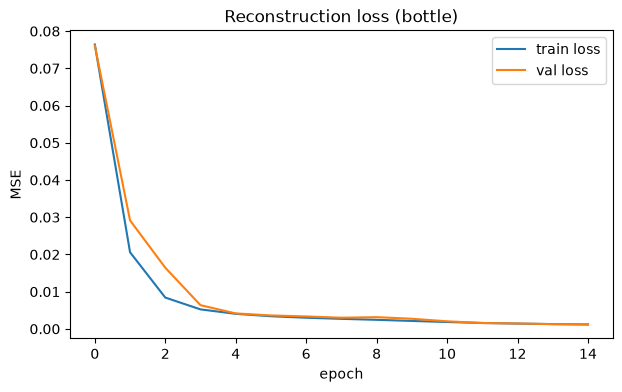

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(history['train'], label='train loss')
plt.plot(history['val'], label='val loss')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.title(f'Reconstruction loss ({CATEGORY})')
plt.legend()
plt.show()

## 5. Reconstructions: Normal vs Defective

The key question: does the reconstruction error concentrate on defects? For a normal test image the error should be uniformly low. For a defective image the model should reconstruct a "normalized" version of the object, leaving high error exactly where the defect is.

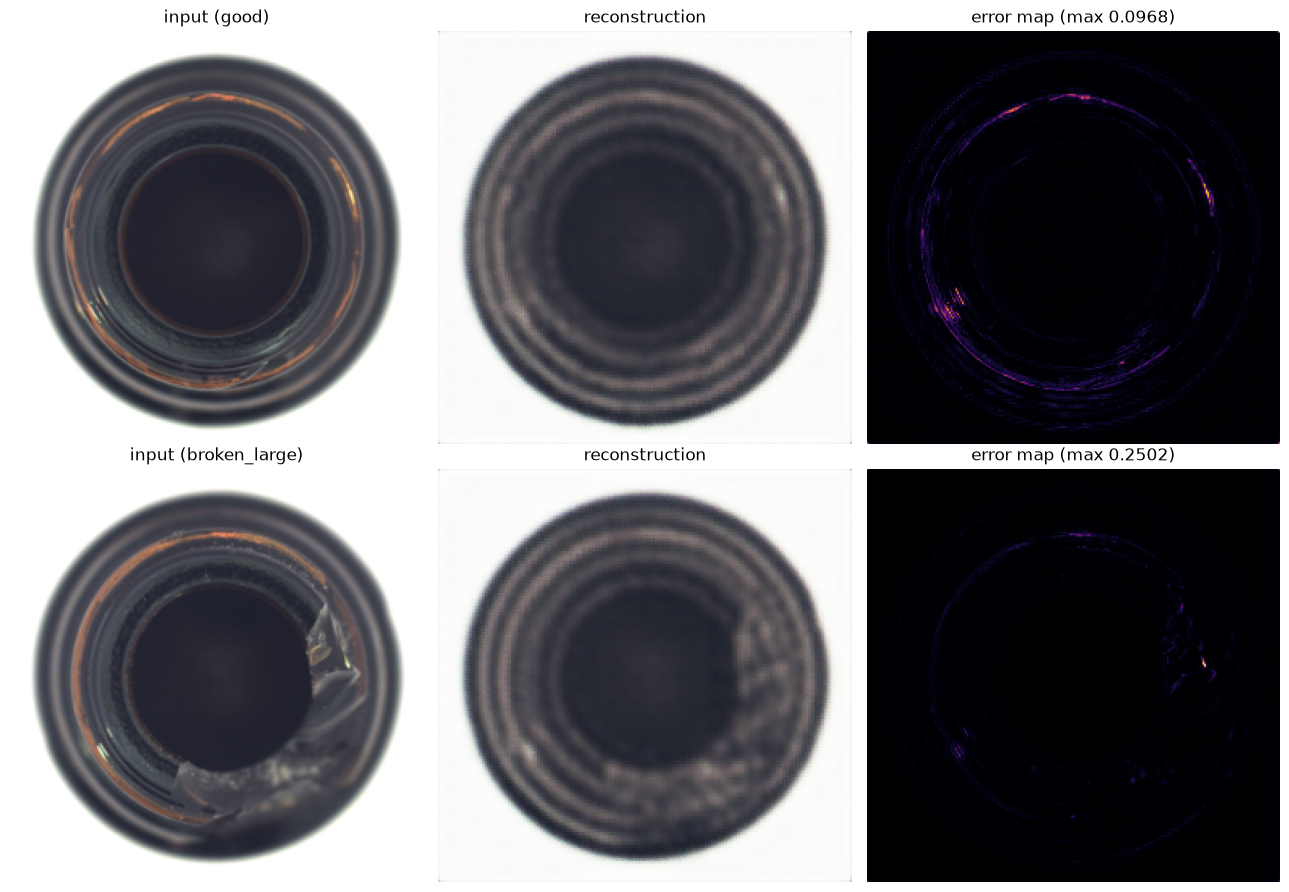

In [8]:
model.eval()

normal_idx = next(i for i, s in enumerate(test_ds.samples) if s[2] == 0)
defect_idx = next(i for i, s in enumerate(test_ds.samples) if s[2] == 1)

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for row, idx in enumerate([normal_idx, defect_idx]):
    sample = test_ds[idx]
    image = sample['image'].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        reconstruction, _ = model(image)
        amap = model.get_anomaly_map(image)

    img_np = image[0].permute(1, 2, 0).cpu().numpy()
    rec_np = reconstruction[0].permute(1, 2, 0).cpu().numpy()
    amap_np = amap[0, 0].cpu().numpy()

    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(f"input ({sample['defect_type']})")
    axes[row, 1].imshow(rec_np)
    axes[row, 1].set_title('reconstruction')
    axes[row, 2].imshow(amap_np, cmap='inferno')
    axes[row, 2].set_title(f'error map (max {amap_np.max():.4f})')
    for ax in axes[row]:
        ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Anomaly Heatmap Overlay

For qualitative inspection we min max normalize the anomaly map, color it with the inferno colormap and alpha blend it onto the original image (alpha 0.5). The same visualization style is used by `scripts/make_qualitative.py` for the report figures.

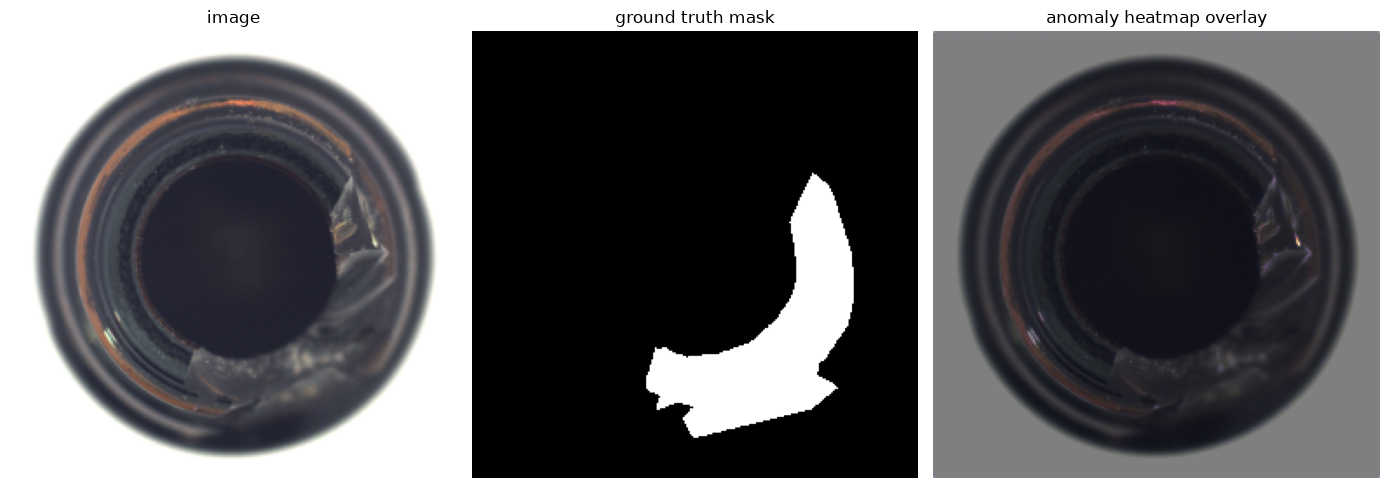

In [9]:
import matplotlib.cm as cm


def heatmap_overlay(img_np, amap_np, alpha=0.5):
    """Min max normalize the map, apply inferno, alpha blend onto the image."""
    norm = amap_np - amap_np.min()
    if norm.max() > 0:
        norm = norm / norm.max()
    heat = cm.inferno(norm)[..., :3]
    return (1 - alpha) * img_np + alpha * heat


sample = test_ds[defect_idx]
image = sample['image'].unsqueeze(0).to(DEVICE)
with torch.no_grad():
    amap = model.get_anomaly_map(image)

img_np = image[0].permute(1, 2, 0).cpu().numpy()
amap_np = amap[0, 0].cpu().numpy()
mask_np = sample['mask'][0].numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img_np); axes[0].set_title('image')
axes[1].imshow(mask_np, cmap='gray'); axes[1].set_title('ground truth mask')
axes[2].imshow(heatmap_overlay(img_np, amap_np)); axes[2].set_title('anomaly heatmap overlay')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Image Level Scoring: Top k Mean Instead of Max

To turn the anomaly map into a single score per image we experimented with two options:

- **max pixel error**: sensitive to a single noisy pixel
- **mean of the top k errors** (k = 100): keeps the strongest anomaly signal but averages away isolated noise

We score the whole test set with both and compare their separation between normal and defective images using AUROC.

AUROC with max pixel error: 0.8976
AUROC with top 100 mean:    0.8230


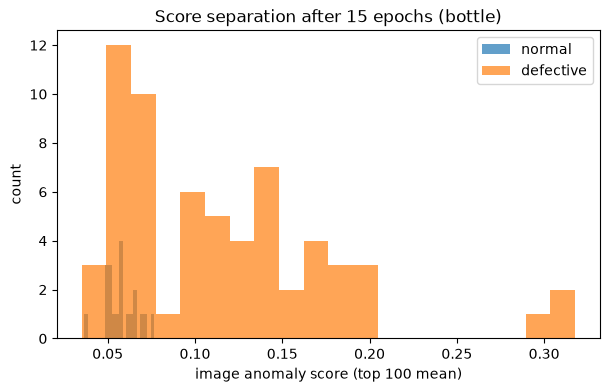

In [10]:
from sklearn.metrics import roc_auc_score

all_labels, scores_topk, scores_max = [], [], []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        images = batch['image'].to(DEVICE)
        amap = model.get_anomaly_map(images)
        scores_topk.extend(model.get_image_score(amap, top_k=100).cpu().tolist())
        scores_max.extend(amap.view(amap.shape[0], -1).max(dim=1).values.cpu().tolist())
        all_labels.extend(batch['label'].tolist())

all_labels = np.array(all_labels)
scores_topk = np.array(scores_topk)
scores_max = np.array(scores_max)

print(f'AUROC with max pixel error: {roc_auc_score(all_labels, scores_max):.4f}')
print(f'AUROC with top 100 mean:    {roc_auc_score(all_labels, scores_topk):.4f}')

plt.figure(figsize=(7, 4))
plt.hist(scores_topk[all_labels == 0], bins=20, alpha=0.7, label='normal')
plt.hist(scores_topk[all_labels == 1], bins=20, alpha=0.7, label='defective')
plt.xlabel('image anomaly score (top 100 mean)')
plt.ylabel('count')
plt.title(f'Score separation after {EPOCHS} epochs ({CATEGORY})')
plt.legend()
plt.show()

## 8. Conclusions From This Experiment

- The architecture is sound: loss decreases steadily and even a short run separates normal from defective bottle images reasonably well.
- Reconstruction error visibly concentrates on defect regions, validating the core idea.
- In this short run the raw max scored slightly higher than the top k mean. Over the full training runs the top k mean proved less sensitive to single noisy pixels, so it became the default in `src/autoencoder.py`.
- Reconstructions are blurry, an inherent property of MSE trained autoencoders. We expect this to limit localization precision and to hurt most on texture categories like carpet, where normal already looks irregular.

The production training script `scripts/train_baseline.py` runs this per category with up to 100 epochs, early stopping (patience 10), a ReduceLROnPlateau scheduler and best checkpoint saving to `results/checkpoints/autoencoder_<category>.pth`.